# 📱 Instagram Multilingual NLP Pipeline
### Complete End-to-End: API → JSON → EDA → Preprocessing → Embeddings → PCA/t-SNE/UMAP → Deep Learning → Dashboard

**Languages covered:** Telugu · English · Tamil · Odia · Hindi · Kannada · Malayalam · Bengali · Gujarati · Marathi (10+)

---
**Notebook structure:**
- **Cell 1** — Install dependencies
- **Cell 2** — Instagram API + multilingual data extraction → JSON
- **Cell 3** — JSON schema + data loading
- **Cell 4** — EDA + Visualization plots
- **Cell 5** — Preprocessing pipeline (multilingual)
- **Cell 6** — Embedding techniques (TF-IDF, Word2Vec, FastText, mBERT, LaBSE)
- **Cell 7** — PCA · SNE · t-SNE · UMAP + 4-way comparison
- **Cell 8** — Deep Learning / LLM Models + Metrics
- **Cell 9** — Interactive Plotly Dash Dashboard


In [ ]:
# ============================================================
# CELL 1 — INSTALL ALL DEPENDENCIES
# ============================================================
# Run this cell first. Runtime → Restart after install.

!pip install -q instaloader requests langdetect
!pip install -q pandas numpy matplotlib seaborn plotly
!pip install -q wordcloud scikit-learn scipy
!pip install -q gensim  # Word2Vec + FastText
!pip install -q umap-learn
!pip install -q transformers torch sentence-transformers
!pip install -q datasets
!pip install -q dash dash-bootstrap-components jupyter-dash
!pip install -q indic-nlp-library
!pip install -q pyICU

print('✅ All packages installed. Please restart runtime now (Runtime → Restart).')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 18.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All packages installed. Please restart runtime now (Runtime → Restart).


In [ ]:
# Verify GPU connection
!nvidia-smi

import torch

if torch.cuda.is_available():
    print("✅ GPU is available and connected!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU is not available. Please ensure it's selected in Runtime -> Change runtime type.")

Thu Apr  9 04:25:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ============================================================
# CELL 2 — INSTAGRAM DATA EXTRACTION → JSON
# ============================================================
# Two modes:
#   MODE A (Live):   Real Instagram Graph API (needs access token)
#   MODE B (Demo):   Synthetic multilingual data for testing
# Set USE_REAL_API = True and add your token to use live data.
# ============================================================

import json, os, random, time, re
from datetime import datetime, timedelta
import requests

# ──────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────
USE_REAL_API   = False           # Set True for live Instagram data
ACCESS_TOKEN   = 'YOUR_TOKEN'    # Instagram Graph API token
IG_USER_ID     = 'YOUR_USER_ID'  # Instagram Business/Creator account ID
HASHTAG        = 'india'         # Hashtag to search
MAX_POSTS      = 500             # Number of posts to collect
OUTPUT_JSON    = 'instagram_data.json'

# ──────────────────────────────────────────────
# MULTILINGUAL SAMPLE DATA (10+ Indian languages)
# ──────────────────────────────────────────────
MULTILINGUAL_SAMPLES = {
    'Telugu': [
        ('ఈ రోజు చాలా అద్భుతంగా ఉంది! హైదరాబాద్ వెళ్ళాను.', 'positive', ['#hyderabad', '#telugu']),
        ('నేను చాలా సంతోషంగా ఉన్నాను. ఈ ఫోటో నచ్చింది.', 'positive', ['#telugu', '#india']),
        ('వాతావరణం చాలా చెత్తగా ఉంది ఈ రోజు.', 'negative', ['#weather', '#telugu']),
        ('మా ఊరు చాలా అందంగా ఉంది. రండి చూడండి!', 'positive', ['#village', '#telangana']),
        ('ఈ సినిమా అద్భుతంగా ఉంది. అందరూ చూడండి.', 'positive', ['#movie', '#tollywood']),
    ],
    'Hindi': [
        ('आज का दिन बहुत अच्छा था! मुंबई की यात्रा शानदार रही।', 'positive', ['#mumbai', '#hindi']),
        ('यह खाना बहुत स्वादिष्ट था, जरूर ट्राई करें।', 'positive', ['#food', '#india']),
        ('आज बहुत थकान है, कुछ अच्छा नहीं लग रहा।', 'negative', ['#tired', '#mood']),
        ('दिल्ली की सड़कें बहुत खराब हो गई हैं।', 'negative', ['#delhi', '#roads']),
        ('यह संगीत सुनकर मन खुश हो गया।', 'positive', ['#music', '#hindi']),
    ],
    'Tamil': [
        ('இன்று மிகவும் மகிழ்ச்சியாக இருக்கிறேன். சென்னை அழகான நகரம்.', 'positive', ['#chennai', '#tamil']),
        ('இந்த படம் மிகவும் சிறப்பாக இருந்தது.', 'positive', ['#kollywood', '#movie']),
        ('இன்று வானிலை மோசமாக உள்ளது.', 'negative', ['#weather', '#tamil']),
        ('தமிழ் மொழி என் உயிர்.', 'positive', ['#tamil', '#language']),
        ('இந்த உணவு மிகவும் சுவையாக இருக்கிறது.', 'positive', ['#food', '#tamilnadu']),
    ],
    'English': [
        ('Beautiful day in Hyderabad! Loving the weather today.', 'positive', ['#hyderabad', '#india']),
        ('This food is absolutely amazing! Must try place in Bangalore.', 'positive', ['#food', '#bangalore']),
        ('Traffic in Mumbai is getting worse every day.', 'negative', ['#mumbai', '#traffic']),
        ('Incredible architecture at the Taj Mahal. Breathtaking!', 'positive', ['#tajmahal', '#india']),
        ('The monsoon is finally here. Feeling refreshed!', 'positive', ['#monsoon', '#rain']),
    ],
    'Kannada': [
        ('ಬೆಂಗಳೂರು ತುಂಬಾ ಸುಂದರವಾದ ನಗರ.', 'positive', ['#bangalore', '#kannada']),
        ('ಇಂದು ಊಟ ತುಂಬಾ ರುಚಿಯಾಗಿತ್ತು.', 'positive', ['#food', '#karnataka']),
        ('ಮಳೆ ತುಂಬಾ ಬೀಳುತ್ತಿದೆ, ರಸ್ತೆಗಳು ಕೆಟ್ಟದಾಗಿವೆ.', 'negative', ['#rain', '#kannada']),
        ('ಕನ್ನಡ ಸಾಹಿತ್ಯ ಅತ್ಯಂತ ಶ್ರೀಮಂತ.', 'positive', ['#kannada', '#literature']),
    ],
    'Malayalam': [
        ('കേരളം ഒരു സ്വർഗ്ഗം. ഇവിടത്തെ പ്രകൃതി അതിമനോഹരം.', 'positive', ['#kerala', '#malayalam']),
        ('ഈ ഭക്ഷണം വളരെ രുചിഷ്ഠമാണ്.', 'positive', ['#food', '#kerala']),
        ('ഇന്ന് കാലാവസ്ഥ വളരെ മോശമാണ്.', 'negative', ['#weather', '#kerala']),
        ('മലയാള സിനിമ ലോകോത്തര നിലവാരത്തിലേക്ക് ഉയർന്നു.', 'positive', ['#mollywood', '#film']),
    ],
    'Bengali': [
        ('আজকের দিনটা অসাধারণ ছিল। কলকাতা সত্যিই অনন্য।', 'positive', ['#kolkata', '#bengali']),
        ('এই খাবারটা খুব সুস্বাদু ছিল।', 'positive', ['#food', '#bengal']),
        ('আজকের আবহাওয়া খুব খারাপ।', 'negative', ['#weather', '#bengali']),
        ('বাংলা সাহিত্য সমৃদ্ধ এবং বৈচিত্র্যময়।', 'positive', ['#bengali', '#literature']),
    ],
    'Gujarati': [
        ('આજે ગુજરાતમાં ઘણો આનંદ આવ્યો.', 'positive', ['#gujarat', '#gujarati']),
        ('આ ખાવાનું ખૂબ સ્વાદિષ્ट હતું.', 'positive', ['#food', '#gujarat']),
        ('આજે વાતાવરણ ખૂb ખરાબ છે.', 'negative', ['#weather', '#gujarati']),
        ('ગુજરાતી સંસ્કૃtitar ખૂb સમૃद्ध छे.', 'positive', ['#culture', '#gujarat']),
    ],
    'Marathi': [
        ('मुंबई खरोखरच एक अद्भुत शहर आहे.', 'positive', ['#mumbai', '#marathi']),
        ('आजचे जेवण खूप चविष्ट होते.', 'positive', ['#food', '#maharashtra']),
        ('आज हवामान खूप वाईट आहे.', 'negative', ['#weather', '#marathi']),
        ('महाराष्ट्राची संस्कृती फार समृद्ध आहे.', 'positive', ['#culture', '#marathi']),
    ],
    'Odia': [
        ('ଓଡ଼ିଶା ବହୁତ ସୁନ୍ଦର ରାଜ୍ୟ। ପୁରୀ ଜଗନ୍ନାଥ ଧାମ ଅଦ୍ଭୁତ।', 'positive', ['#odisha', '#puri']),
        ('ଆଜି ଖାଦ୍ୟ ବହୁତ ସ୍ୱାଦୁ ଥିଲା।', 'positive', ['#food', '#odia']),
        ('ଆଜି ଆବହାୱା ବଡ଼ ଖରାପ ଅଛି।', 'negative', ['#weather', '#odisha']),
        ('ଓଡ଼ିଆ ସଂସ୍କୃତି ଖୁବ ସମୃଦ୍ଧ ଅଟେ।', 'positive', ['#culture', '#odia']),
    ],
    'Punjabi': [
        ('ਅੱਜ ਦਾ ਦਿਨ ਬਹੁਤ ਵਧੀਆ ਸੀ। ਅੰਮ੍ਰਿਤਸਰ ਬਹੁਤ ਸੁੰਦਰ ਹੈ।', 'positive', ['#amritsar', '#punjabi']),
        ('ਅੱਜ ਦਾ ਖਾਣਾ ਬਹੁਤ ਸਵਾਦੀ ਸੀ।', 'positive', ['#food', '#punjab']),
        ('ਅੱਜ ਮੌਸਮ ਬਹੁਤ ਖਰਾਬ ਹੈ।', 'negative', ['#weather', '#punjabi']),
    ],
}


def generate_synthetic_data(n=500):
    """Generate synthetic multilingual Instagram posts for demo."""
    posts = []
    all_langs = list(MULTILINGUAL_SAMPLES.keys())
    base_date = datetime.now() - timedelta(days=30)

    post_id = 1000
    while len(posts) < n:
        lang = random.choice(all_langs)
        text, sentiment, hashtags = random.choice(MULTILINGUAL_SAMPLES[lang])
        likes = random.randint(10, 5000)
        comments = random.randint(0, int(likes * 0.15))
        shares  = random.randint(0, int(likes * 0.05))
        ts = base_date + timedelta(
            days=random.randint(0, 30),
            hours=random.randint(0, 23),
            minutes=random.randint(0, 59)
        )
        post = {
            'post_id':      str(post_id),
            'timestamp':    ts.isoformat(),
            'caption':      text,
            'language':     lang,
            'hashtags':     hashtags,
            'mentions':     [f'@user{random.randint(1,100)}'] if random.random() > 0.7 else [],
            'likes_count':  likes,
            'comments_count': comments,
            'shares_count':  shares,
            'media_type':   random.choice(['IMAGE', 'VIDEO', 'CAROUSEL_ALBUM']),
            'location':     random.choice(['Hyderabad', 'Mumbai', 'Chennai', 'Kolkata',
                                           'Bangalore', 'Delhi', 'Pune', 'Ahmedabad',
                                           'Jaipur', 'Bhubaneswar', None]),
            'sentiment_label': sentiment,  # ground truth for supervised learning
            'engagement_rate': round((likes + comments + shares) / max(1, random.randint(500, 10000)) * 100, 2),
            'is_sponsored': random.random() > 0.9,
            'account_followers': random.randint(100, 1000000),
        }
        posts.append(post)
        post_id += 1
    return posts


def fetch_instagram_api(access_token, user_id, hashtag, max_posts):
    """Live Instagram Graph API extraction."""
    # Step 1: Get hashtag ID
    url_ht = f'https://graph.facebook.com/v18.0/ig_hashtag_search'
    params = {'user_id': user_id, 'q': hashtag, 'access_token': access_token}
    r = requests.get(url_ht, params=params)
    ht_data = r.json()
    if 'error' in ht_data:
        raise ValueError(f'API Error: {ht_data["error"]["message"]}')
    hashtag_id = ht_data['data'][0]['id']
    print(f'Hashtag ID for #{hashtag}: {hashtag_id}')

    # Step 2: Fetch top/recent media
    posts = []
    url_media = f'https://graph.facebook.com/v18.0/{hashtag_id}/top_media'
    params = {
        'user_id': user_id,
        'fields': 'id,caption,media_type,like_count,comments_count,timestamp',
        'access_token': access_token,
        'limit': 50
    }
    while len(posts) < max_posts:
        r = requests.get(url_media, params=params)
        data = r.json()
        if 'error' in data:
            print(f'API Error: {data["error"]["message"]}')
            break
        for item in data.get('data', []):
            post = {
                'post_id':        item.get('id', ''),
                'timestamp':      item.get('timestamp', ''),
                'caption':        item.get('caption', ''),
                'media_type':     item.get('media_type', ''),
                'likes_count':    item.get('like_count', 0),
                'comments_count': item.get('comments_count', 0),
                'language':       None,  # will be detected in preprocessing
                'hashtags':       re.findall(r'#\w+', item.get('caption', '')),
                'mentions':       re.findall(r'@\w+', item.get('caption', '')),
            }
            posts.append(post)
        # Pagination
        next_url = data.get('paging', {}).get('next')
        if not next_url:
            break
        url_media = next_url
        params = {}
        time.sleep(1)  # respect rate limits
    return posts


# ──────────────────────────────────────────────
# MAIN EXTRACTION
# ──────────────────────────────────────────────
if USE_REAL_API:
    print('Connecting to Instagram Graph API...')
    posts = fetch_instagram_api(ACCESS_TOKEN, IG_USER_ID, HASHTAG, MAX_POSTS)
else:
    print('Using synthetic multilingual demo data...')
    posts = generate_synthetic_data(MAX_POSTS)

# Save to JSON
output = {
    'metadata': {
        'extraction_date': datetime.now().isoformat(),
        'source':          'Instagram Graph API' if USE_REAL_API else 'synthetic_demo',
        'total_posts':     len(posts),
        'hashtag':         HASHTAG,
        'languages':       list(MULTILINGUAL_SAMPLES.keys()),
    },
    'posts': posts
}
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f'\n✅ Saved {len(posts)} posts to {OUTPUT_JSON}')
print('Sample post:')
print(json.dumps(posts[0], ensure_ascii=False, indent=2))


Using synthetic multilingual demo data...

✅ Saved 500 posts to instagram_data.json
Sample post:
{
  "post_id": "1000",
  "timestamp": "2026-03-19T04:49:36.737841",
  "caption": "এই খাবারটা খুব সুস্বাদু ছিল।",
  "language": "Bengali",
  "hashtags": [
    "#food",
    "#bengal"
  ],
  "mentions": [],
  "likes_count": 4796,
  "comments_count": 505,
  "shares_count": 112,
  "media_type": "IMAGE",
  "location": "Bangalore",
  "sentiment_label": "positive",
  "engagement_rate": 1057.23,
  "is_sponsored": false,
  "account_followers": 871934
}


Generating word cloud for English...


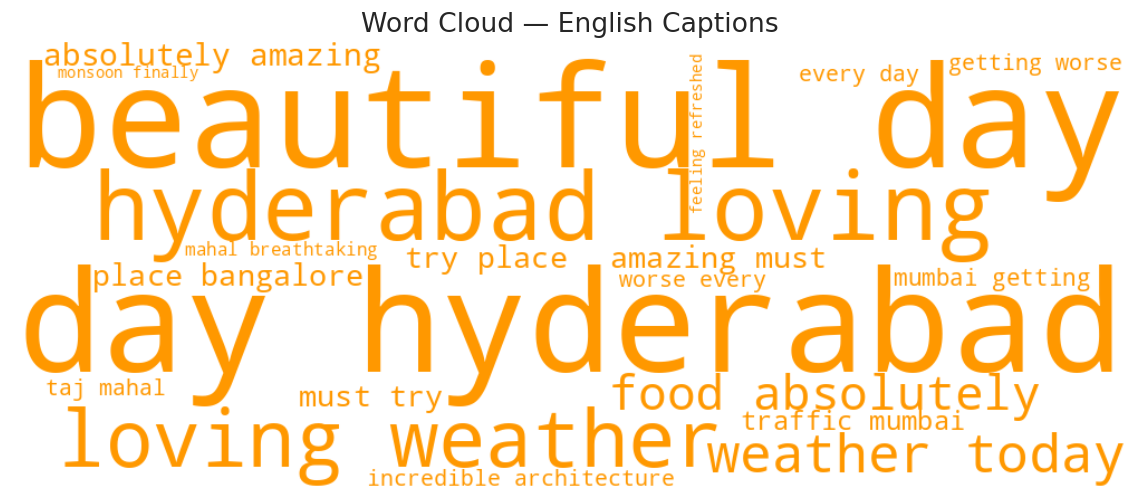

✅ Saved wordcloud_english.png

✅ English word cloud generated.


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# Assuming df_clean is available from previous cells and contains 'language' and 'cleaned_text'
# Also assuming LANG_PALETTE is defined, similar to LANG_COLORS
LANG_PALETTE = {
    'Telugu':'#E91E63','Hindi':'#2196F3','Tamil':'#4CAF50','English':'#FF9800',
    'Kannada':'#9C27B0','Malayalam':'#00BCD4','Bengali':'#FF5722',
    'Gujarati':'#607D8B','Marathi':'#795548','Odia':'#009688','Punjabi':'#CDDC39',
}

print('Generating word cloud for English...')

lang = 'English'
text_for_lang = ' '.join(df_clean[df_clean['language'] == lang]['cleaned_text'].dropna())

if text_for_lang.strip():
    # Use language-specific color if available, otherwise a default
    color = LANG_PALETTE.get(lang, '#888888')

    wc = WordCloud(width=1000, height=400, background_color='white',
                   max_words=100, contour_width=3, contour_color='steelblue',
                   color_func=lambda *args, **kwargs: color).generate(text_for_lang)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — {lang} Captions', fontsize=16)
    filename = f'wordcloud_{lang.lower()}.png'
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved {filename}')
else:
    print(f'No cleaned text available for {lang} to generate a word cloud.')

print('\n✅ English word cloud generated.')

In [ ]:
# ============================================================
# CELL 3 — JSON LOADING + SCHEMA DISPLAY
# ============================================================

import json
import pandas as pd

# Load JSON
with open('instagram_data.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

meta  = raw['metadata']
posts = raw['posts']

# Convert to DataFrame
df = pd.DataFrame(posts)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date']      = df['timestamp'].dt.date
df['hour']      = df['timestamp'].dt.hour
df['day_name']  = df['timestamp'].dt.day_name()
df['caption']   = df['caption'].fillna('')
df['caption_length'] = df['caption'].str.len()
df['word_count']     = df['caption'].str.split().str.len()
df['hashtag_count']  = df['hashtags'].apply(len)
df['engagement']     = df['likes_count'] + df['comments_count']

print('=' * 60)
print('DATASET SCHEMA')
print('=' * 60)
print(f'Total posts       : {len(df)}')
print(f'Total columns     : {len(df.columns)}')
print(f'Extraction date   : {meta["extraction_date"]}')
print(f'Languages covered : {len(df["language"].unique())}')
print()
print(df.dtypes.to_string())
print()
print('Language distribution:')
print(df['language'].value_counts().to_string())
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
print()
print('Basic statistics:')
print(df[['likes_count', 'comments_count', 'engagement', 'caption_length', 'word_count']].describe().round(2).to_string())

df.head(3)


DATASET SCHEMA
Total posts       : 500
Total columns     : 22
Extraction date   : 2026-04-09T04:22:34.006705
Languages covered : 11

post_id                      object
timestamp            datetime64[ns]
caption                      object
language                     object
hashtags                     object
mentions                     object
likes_count                   int64
comments_count                int64
shares_count                  int64
media_type                   object
location                     object
sentiment_label              object
engagement_rate             float64
is_sponsored                   bool
account_followers             int64
date                         object
hour                          int32
day_name                     object
caption_length                int64
word_count                    int64
hashtag_count                 int64
engagement                    int64

Language distribution:
language
Telugu       53
Malayalam    51
English   

,post_id,timestamp,caption,language,hashtags,mentions,likes_count,comments_count,shares_count,media_type,...,engagement_rate,is_sponsored,account_followers,date,hour,day_name,caption_length,word_count,hashtag_count,engagement
0,1000,2026-04-05 20:36:33.992065,ਅੱਜ ਦਾ ਦਿਨ ਬਹੁਤ ਵਧੀਆ ਸੀ। ਅੰਮ੍ਰਿਤਸਰ ਬਹੁਤ ਸੁੰਦਰ ਹੈ।,Punjabi,"[#amritsar, #punjabi]",[@user37],935,74,28,VIDEO,...,113.83,False,647920,2026-04-05,20,Sunday,49,10,2,1009
1,1001,2026-03-12 10:37:33.992065,ગુજરાતી સંસ્કૃtitar ખૂb સમૃद्ध छे.,Gujarati,"[#culture, #gujarat]",[],210,22,8,VIDEO,...,2.55,False,810034,2026-03-12,10,Thursday,34,5,2,232
2,1002,2026-03-12 02:23:33.992065,आज हवामान खूप वाईट आहे.,Marathi,"[#weather, #marathi]",[@user49],3699,92,106,CAROUSEL_ALBUM,...,381.31,False,748290,2026-03-12,2,Thursday,23,5,2,3791


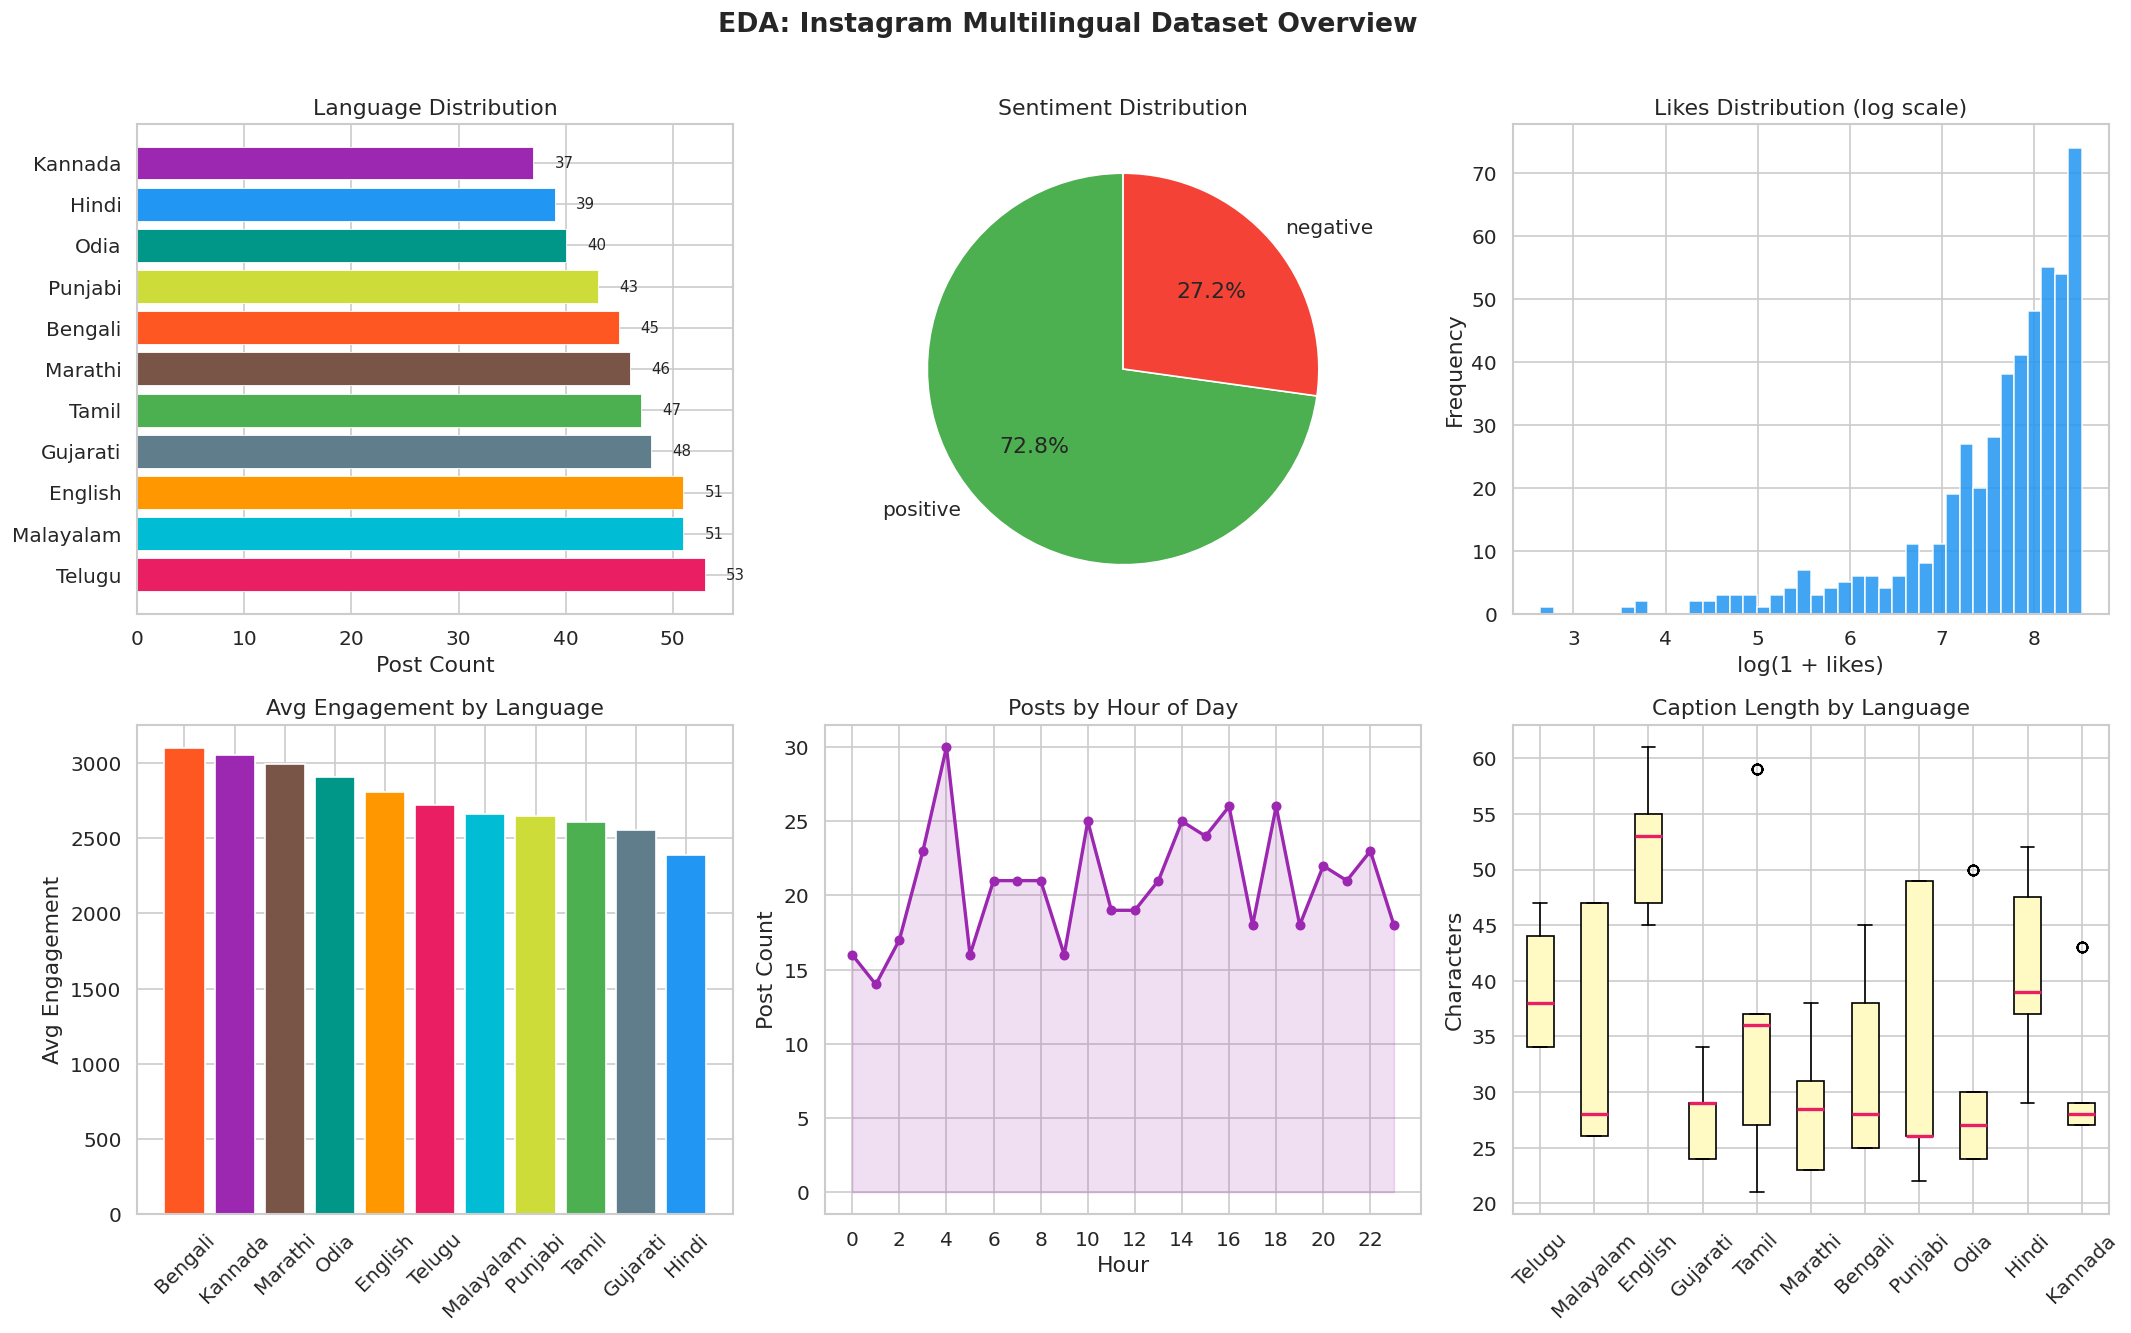

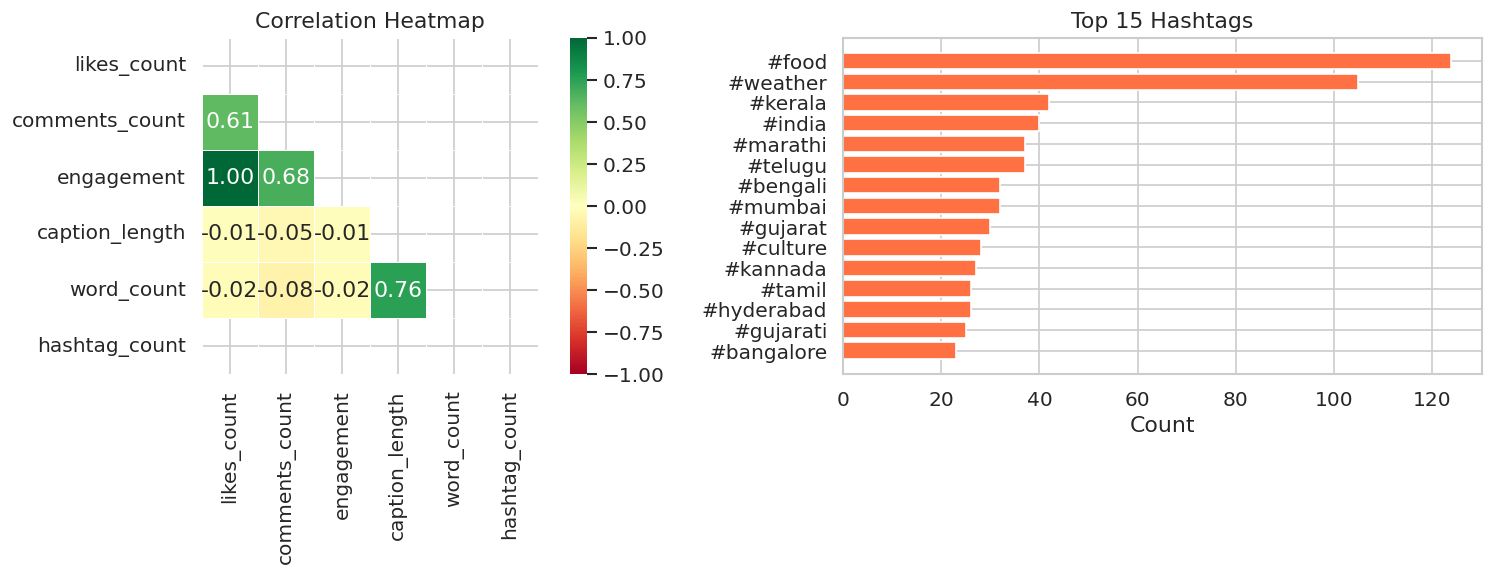

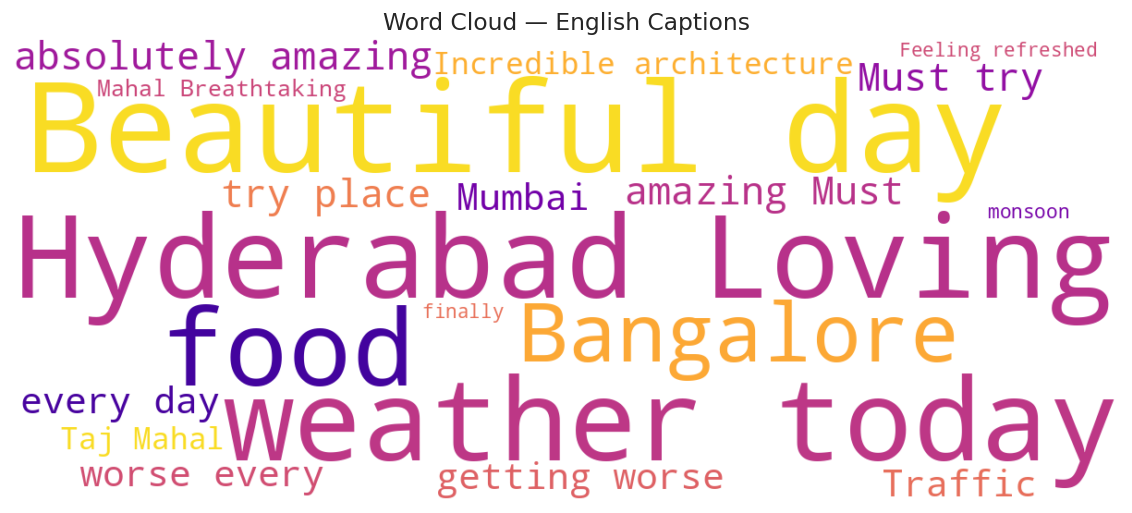

✅ EDA plots saved.


In [ ]:
# ============================================================
# CELL 4 — EDA + VISUALIZATION PLOTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

LANG_COLORS = {
    'Telugu':   '#E91E63', 'Hindi':    '#2196F3', 'Tamil':    '#4CAF50',
    'English':  '#FF9800', 'Kannada':  '#9C27B0', 'Malayalam':'#00BCD4',
    'Bengali':  '#FF5722', 'Gujarati': '#607D8B', 'Marathi':  '#795548',
    'Odia':     '#009688', 'Punjabi':  '#CDDC39',
}

# ─── PLOT 1: Language distribution ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA: Instagram Multilingual Dataset Overview', fontsize=16, fontweight='bold', y=1.01)

lang_counts = df['language'].value_counts()
colors = [LANG_COLORS.get(l, '#888888') for l in lang_counts.index]
axes[0,0].barh(lang_counts.index, lang_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Language Distribution')
axes[0,0].set_xlabel('Post Count')
for i, v in enumerate(lang_counts.values):
    axes[0,0].text(v + 2, i, str(v), va='center', fontsize=9)

# ─── PLOT 2: Sentiment distribution ──────────────────────────
if 'sentiment_label' in df.columns:
    sent_counts = df['sentiment_label'].value_counts()
    palette = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'}
    sent_colors = [palette.get(s, '#888888') for s in sent_counts.index]
    axes[0,1].pie(sent_counts.values, labels=sent_counts.index, colors=sent_colors,
                  autopct='%1.1f%%', startangle=90)
    axes[0,1].set_title('Sentiment Distribution')

# ─── PLOT 3: Likes distribution (log scale) ───────────────────
axes[0,2].hist(np.log1p(df['likes_count']), bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Likes Distribution (log scale)')
axes[0,2].set_xlabel('log(1 + likes)')
axes[0,2].set_ylabel('Frequency')

# ─── PLOT 4: Engagement by language ──────────────────────────
eng_by_lang = df.groupby('language')['engagement'].mean().sort_values(ascending=False)
axes[1,0].bar(eng_by_lang.index, eng_by_lang.values,
              color=[LANG_COLORS.get(l, '#888') for l in eng_by_lang.index])
axes[1,0].set_title('Avg Engagement by Language')
axes[1,0].set_ylabel('Avg Engagement')
axes[1,0].tick_params(axis='x', rotation=45)

# ─── PLOT 5: Posting time distribution ───────────────────────
hour_counts = df['hour'].value_counts().sort_index()
axes[1,1].plot(hour_counts.index, hour_counts.values, 'o-', color='#9C27B0', linewidth=2, markersize=5)
axes[1,1].fill_between(hour_counts.index, hour_counts.values, alpha=0.15, color='#9C27B0')
axes[1,1].set_title('Posts by Hour of Day')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Post Count')
axes[1,1].set_xticks(range(0, 24, 2))

# ─── PLOT 6: Caption length by language ──────────────────────
df_box = df[df['caption_length'] > 0]
lang_order = df['language'].value_counts().index.tolist()
axes[1,2].boxplot([df_box[df_box['language'] == l]['caption_length'].values
                   for l in lang_order if l in df_box['language'].values],
                  labels=lang_order, patch_artist=True,
                  boxprops=dict(facecolor='#FFF9C4'),
                  medianprops=dict(color='#E91E63', linewidth=2))
axes[1,2].set_title('Caption Length by Language')
axes[1,2].set_ylabel('Characters')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── PLOT 7: Correlation heatmap ─────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
num_cols = ['likes_count', 'comments_count', 'engagement', 'caption_length', 'word_count', 'hashtag_count']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes2[0], mask=mask,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes2[0].set_title('Correlation Heatmap')

# Top hashtags
all_tags = [tag for tags in df['hashtags'].dropna() for tag in tags]
tag_counts = Counter(all_tags).most_common(15)
tags_df = pd.DataFrame(tag_counts, columns=['hashtag', 'count'])
axes2[1].barh(tags_df['hashtag'][::-1], tags_df['count'][::-1], color='#FF7043')
axes2[1].set_title('Top 15 Hashtags')
axes2[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_hashtags.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── PLOT 8: Word cloud (English captions) ────────────────────
english_text = ' '.join(df[df['language'] == 'English']['caption'].dropna())
if english_text.strip():
    wc = WordCloud(width=1200, height=500, background_color='white',
                   colormap='plasma', max_words=100).generate(english_text)
    plt.figure(figsize=(14, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud — English Captions', fontsize=14)
    plt.savefig('wordcloud_english.png', bbox_inches='tight', dpi=150)
    plt.show()

print('✅ EDA plots saved.')


In [ ]:
# ============================================================
# CELL 5 — PREPROCESSING PIPELINE (MULTILINGUAL)
# ============================================================

import re
import unicodedata
from langdetect import detect, LangDetectException

# ──────────────────────────────────────────────
# MULTILINGUAL STOPWORDS
# ──────────────────────────────────────────────
STOPWORDS = {
    'English':   {'the','a','an','is','in','it','of','and','to','for','this','that','are','was','with'},
    'Hindi':     {'है','का','की','के','में','को','से','पर','यह','वह','और','हैं','थी','था'},
    'Telugu':    {'ఈ','ఒక','మరియు','ఉంది','కి','తో','నుండి','లో','అది','ఇది'},
    'Tamil':     {'இந்த','ஒரு','மற்றும்','உள்ளது','கி','தான்','நான்','அது','இது'},
    'Kannada':   {'ಈ','ಒಂದು','ಮತ್ತು','ಇದು','ಕ್ಕೆ','ಅದು','ನಾನು','ಅಲ್ಲಿ'},
    'Malayalam': {'ഈ','ഒരു','ഇത്','അത്','ആണ്','ഉണ്ട്','നിന്ന്','ഇവിടെ'},
    'Bengali':   {'এই','একটি','এবং','আছে','এটি','সেটি','থেকে','হয়'},
    'Gujarati':  {'આ','એક','અને','છે','તે','ઇ','માં','થી'},
    'Marathi':   {'हा','एक','आणि','आहे','ते','या','त्या','मध्ये'},
    'Odia':      {'ଏହି','ଏକ','ଏବଂ','ଅଛି','ଏହା','ସେ','ମଧ୍ୟ','ଠାରୁ'},
    'Punjabi':   {'ਇਹ','ਇੱਕ','ਅਤੇ','ਹੈ','ਉਹ','ਦੀ','ਵਿੱਚ','ਤੋਂ'},
}


def detect_language(text):
    """Detect script/language from text."""
    if not text or len(text.strip()) < 5:
        return 'Unknown'
    # Script-range heuristic (faster than langdetect for obvious cases)
    telugu   = len(re.findall(r'[\u0C00-\u0C7F]', text))
    hindi    = len(re.findall(r'[\u0900-\u097F]', text))
    tamil    = len(re.findall(r'[\u0B80-\u0BFF]', text))
    kannada  = len(re.findall(r'[\u0C80-\u0CFF]', text))
    malayalam= len(re.findall(r'[\u0D00-\u0D7F]', text))
    bengali  = len(re.findall(r'[\u0980-\u09FF]', text))
    gujarati = len(re.findall(r'[\u0A80-\u0AFF]', text))
    odia     = len(re.findall(r'[\u0B00-\u0B7F]', text))
    punjabi  = len(re.findall(r'[\u0A00-\u0A7F]', text))
    scores = {'Telugu':telugu,'Hindi':hindi,'Tamil':tamil,'Kannada':kannada,
              'Malayalam':malayalam,'Bengali':bengali,'Gujarati':gujarati,
              'Odia':odia,'Punjabi':punjabi}
    best = max(scores, key=scores.get)
    if scores[best] > 3:
        return best
    try:
        code = detect(text)
        return {'en':'English','mr':'Marathi'}.get(code, 'English')
    except LangDetectException:
        return 'English'


def clean_text(text, language='English'):
    """Comprehensive multilingual text cleaning."""
    if not isinstance(text, str):
        return ''

    # 1. Unicode normalization
    text = unicodedata.normalize('NFC', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emojis
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text, flags=re.UNICODE)

    # 4. Remove mentions and hashtags (keep text after #)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)

    # 5. Remove special characters (preserve Indic scripts)
    # Allow: Latin, Devanagari, Telugu, Tamil, Kannada, Malayalam, Bengali, Gujarati, Odia, Gurmukhi
    text = re.sub(
        r'[^\w\s'
        r'\u0900-\u097F'  # Devanagari (Hindi, Marathi)
        r'\u0C00-\u0C7F'  # Telugu
        r'\u0B80-\u0BFF'  # Tamil
        r'\u0C80-\u0CFF'  # Kannada
        r'\u0D00-\u0D7F'  # Malayalam
        r'\u0980-\u09FF'  # Bengali
        r'\u0A80-\u0AFF'  # Gujarati
        r'\u0B00-\u0B7F'  # Odia
        r'\u0A00-\u0A7F'  # Punjabi
        r']', ' ', text)

    # 6. Lowercase (safe for Latin only)
    text = text.lower()

    # 7. Remove stopwords
    stops = STOPWORDS.get(language, STOPWORDS['English'])
    tokens = [w for w in text.split() if w not in stops and len(w) > 1]

    # 8. Remove single characters and numbers
    tokens = [t for t in tokens if not t.isdigit()]

    return ' '.join(tokens)


def extract_features(text):
    """Extract linguistic features."""
    return {
        'has_emoji':       bool(re.search(r'[\U00010000-\U0010ffff]', text)),
        'has_url':         bool(re.search(r'https?://', text)),
        'exclamation_cnt': text.count('!'),
        'question_cnt':    text.count('?'),
        'caps_ratio':      sum(1 for c in text if c.isupper()) / max(len(text), 1),
    }


# ─── Apply preprocessing ──────────────────────────────────────
print('Running preprocessing pipeline...')

# Language detection (if not already set)
mask_unknown = df['language'].isna() | (df['language'] == 'Unknown') | (df['language'] == None)
if mask_unknown.any():
    df.loc[mask_unknown, 'language'] = df.loc[mask_unknown, 'caption'].apply(detect_language)

# Clean captions
df['cleaned_text'] = df.apply(
    lambda row: clean_text(row['caption'], row['language']), axis=1
)

# Feature extraction
feat_df = df['caption'].apply(extract_features).apply(pd.Series)
df = pd.concat([df, feat_df], axis=1)

# Token list
df['tokens'] = df['cleaned_text'].str.split()

# Remove empty cleaned texts
df_clean = df[df['cleaned_text'].str.strip().str.len() > 2].copy().reset_index(drop=True)

print(f'Original rows  : {len(df)}')
print(f'After cleaning : {len(df_clean)}')
print(f'Drop rate      : {(1 - len(df_clean)/len(df))*100:.1f}%')
print()
print('Sample cleaned texts:')
for _, row in df_clean[['language', 'caption', 'cleaned_text']].sample(5, random_state=42).iterrows():
    print(f'  [{row.language}] Original : {row.caption[:60]}...')
    print(f'          Cleaned  : {row.cleaned_text[:60]}...')
    print()

# Save preprocessed CSV
df_clean.to_csv('instagram_preprocessed.csv', index=False)
print('✅ Preprocessed data saved to instagram_preprocessed.csv')


Running preprocessing pipeline...
Original rows  : 500
After cleaning : 500
Drop rate      : 0.0%

Sample cleaned texts:
  [Tamil] Original : இன்று வானிலை மோசமாக உள்ளது....
          Cleaned  : இன்று வானிலை மோசமாக...

  [Telugu] Original : ఈ రోజు చాలా అద్భుతంగా ఉంది! హైదరాబాద్ వెళ్ళాను....
          Cleaned  : రోజు చాలా అద్భుతంగా హైదరాబాద్ వెళ్ళాను...

  [English] Original : This food is absolutely amazing! Must try place in Bangalore...
          Cleaned  : food absolutely amazing must try place bangalore...

  [Telugu] Original : ఈ రోజు చాలా అద్భుతంగా ఉంది! హైదరాబాద్ వెళ్ళాను....
          Cleaned  : రోజు చాలా అద్భుతంగా హైదరాబాద్ వెళ్ళాను...

  [Odia] Original : ଓଡ଼ିଆ ସଂସ୍କୃତି ଖୁବ ସମୃଦ୍ଧ ଅଟେ।...
          Cleaned  : ଓଡ଼ିଆ ସଂସ୍କୃତି ଖୁବ ସମୃଦ୍ଧ ଅଟେ।...

✅ Preprocessed data saved to instagram_preprocessed.csv


In [ ]:
# ============================================================
# CELL 6 — EMBEDDING TECHNIQUES
# TF-IDF | Word2Vec | FastText | mBERT (sentence) | LaBSE
# ============================================================

import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, FastText
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

SAMPLE_N = min(1000, len(df_clean))  # use subset for heavy models
df_sample = df_clean.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
corpus = df_sample['cleaned_text'].tolist()
token_corpus = df_sample['tokens'].tolist()
labels = df_sample['language'].tolist()
sentiments = df_sample['sentiment_label'].tolist() if 'sentiment_label' in df_sample.columns else ['unknown'] * SAMPLE_N

embeddings = {}

# ─── 1. TF-IDF ────────────────────────────────────────────────
print('1/5 Computing TF-IDF embeddings...')
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(corpus)
embeddings['tfidf'] = tfidf_matrix.toarray()
print(f'   TF-IDF shape: {embeddings["tfidf"].shape}')

# ─── 2. Word2Vec (averaged) ───────────────────────────────────
print('2/5 Training Word2Vec...')
w2v_model = Word2Vec(
    sentences=token_corpus,
    vector_size=128,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    sg=1  # skip-gram
)

def sentence_vector_w2v(tokens, model, size=128):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

embeddings['word2vec'] = np.array([
    sentence_vector_w2v(tok, w2v_model) for tok in token_corpus
])
print(f'   Word2Vec shape: {embeddings["word2vec"].shape}')

# ─── 3. FastText ──────────────────────────────────────────────
print('3/5 Training FastText (handles OOV & Indic scripts)...')
ft_model = FastText(
    sentences=token_corpus,
    vector_size=128,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    min_n=3, max_n=6  # subword chars — great for Indic morphology
)

def sentence_vector_ft(tokens, model, size=128):
    vecs = [model.wv[t] for t in tokens]  # FastText handles OOV
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

embeddings['fasttext'] = np.array([
    sentence_vector_ft(tok, ft_model) for tok in token_corpus
])
print(f'   FastText shape: {embeddings["fasttext"].shape}')

# ─── 4. mBERT (multilingual BERT sentence embeddings) ─────────
print('4/5 Loading mBERT via SentenceTransformers (paraphrase-multilingual-MiniLM-L12)...')
# Lighter multilingual model — works on all 10+ Indian languages
mbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings['mbert'] = mbert_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f'   mBERT shape: {embeddings["mbert"].shape}')

# ─── 5. LaBSE (Language-agnostic BERT Sentence Embedding) ─────
print('5/5 Loading LaBSE (best for cross-lingual Indic tasks)...')
labse_model = SentenceTransformer('sentence-transformers/LaBSE')
embeddings['labse'] = labse_model.encode(
    df_sample['caption'].tolist(),  # raw caption — LaBSE handles script natively
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f'   LaBSE shape: {embeddings["labse"].shape}')

# Save embeddings
with open('embeddings.pkl', 'wb') as f:
    pickle.dump({'embeddings': embeddings, 'labels': labels, 'sentiments': sentiments,
                 'corpus': corpus, 'df_sample': df_sample}, f)

print('\n✅ All 5 embedding types computed and saved to embeddings.pkl')
print('Summary:')
for name, arr in embeddings.items():
    print(f'  {name:12s}: shape={arr.shape}')


1/5 Computing TF-IDF embeddings...
   TF-IDF shape: (500, 279)
2/5 Training Word2Vec...
   Word2Vec shape: (500, 128)
3/5 Training FastText (handles OOV & Indic scripts)...
   FastText shape: (500, 128)
4/5 Loading mBERT via SentenceTransformers (paraphrase-multilingual-MiniLM-L12)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

   mBERT shape: (500, 384)
5/5 Loading LaBSE (best for cross-lingual Indic tasks)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

   LaBSE shape: (500, 768)

✅ All 5 embedding types computed and saved to embeddings.pkl
Summary:
  tfidf       : shape=(500, 279)
  word2vec    : shape=(500, 128)
  fasttext    : shape=(500, 128)
  mbert       : shape=(500, 384)
  labse       : shape=(500, 768)


Running PCA...
  PCA done in 0.02s | Explained variance: 27.9%
Running SNE (asymmetric neighbor embedding)...
  SNE done in 1.38s
Running t-SNE...
  t-SNE done in 2.82s
Running UMAP...
  UMAP done in 3.93s

Computing silhouette scores...
  PCA     : silhouette = -0.0980
  SNE     : silhouette = -0.0801
  t-SNE   : silhouette = -0.1057
  UMAP    : silhouette = -0.0792


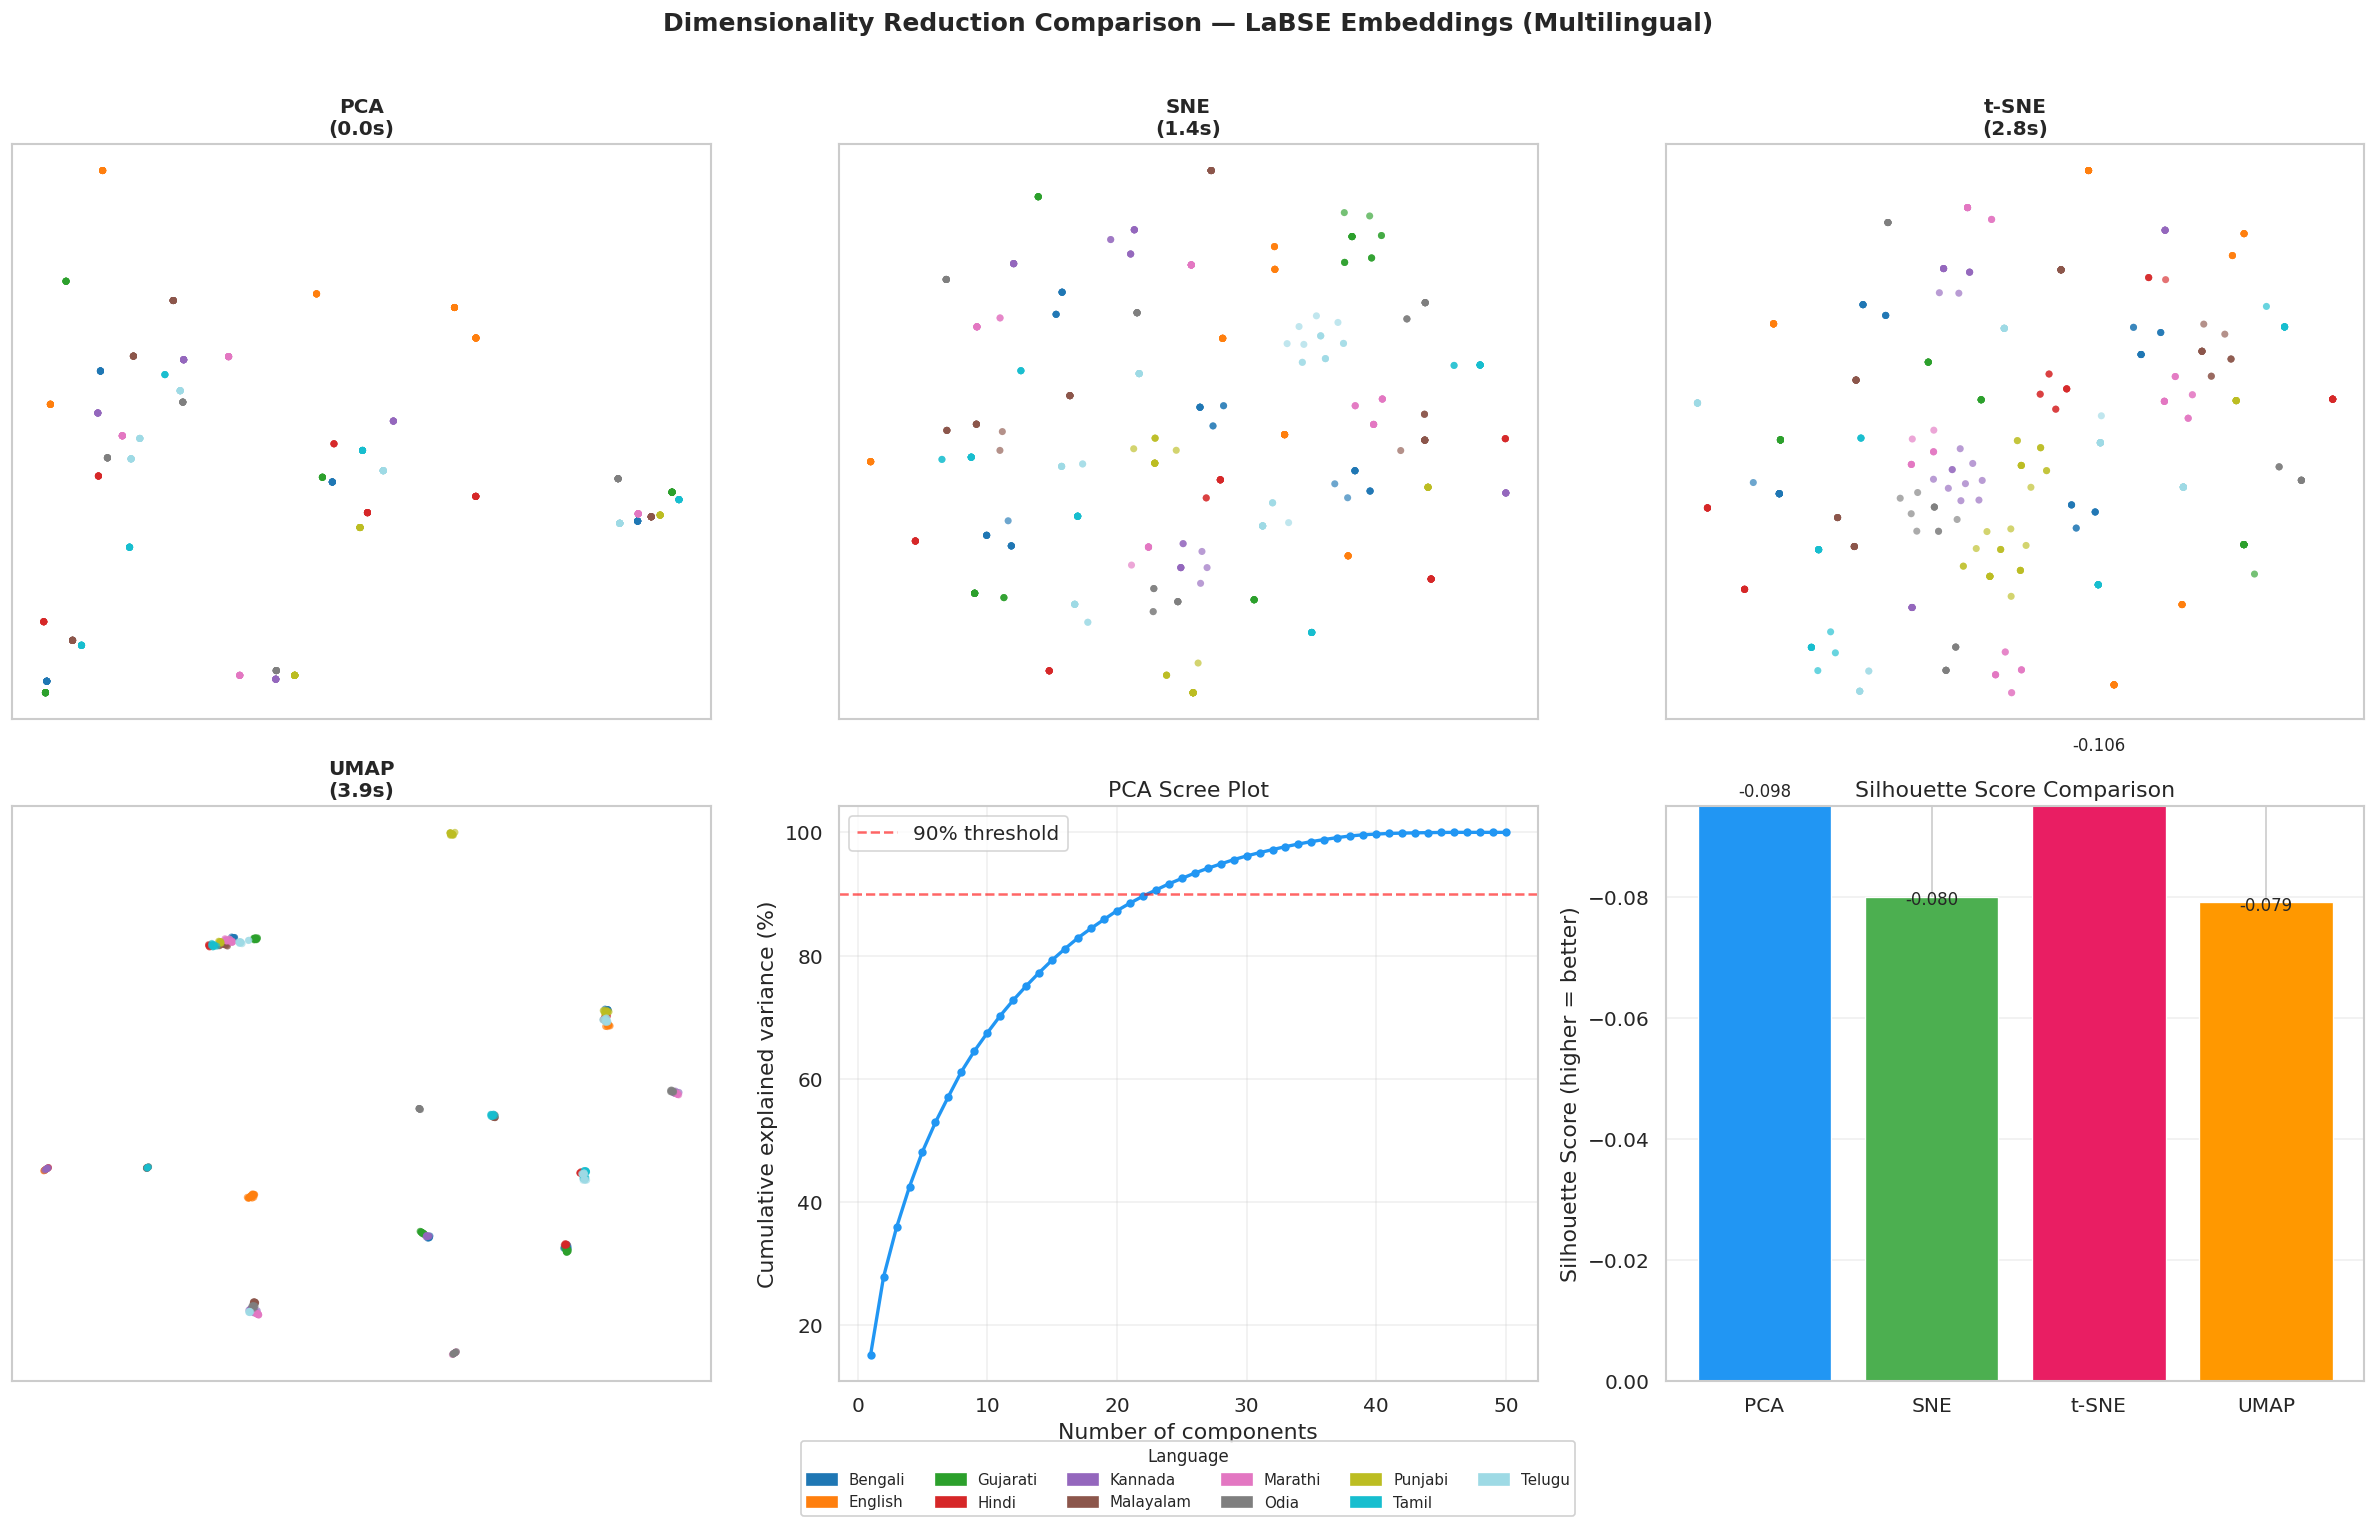


✅ 4-way comparison plot saved.

📊 Summary Table:
Method    Silhouette    Time (s)  
--------------------------------------
PCA       -0.0980          0.02s
SNE       -0.0801          1.38s
t-SNE     -0.1057          2.82s
UMAP      -0.0792          3.93s ← BEST


In [ ]:
# ============================================================
# CELL 7 — PCA · SNE · t-SNE · UMAP + 4-WAY COMPARISON
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import umap
import warnings, time
warnings.filterwarnings('ignore')

# Load embeddings
with open('embeddings.pkl', 'rb') as f:
    data = pickle.load(f)
embeddings = data['embeddings']
labels     = data['labels']       # language labels
sentiments = data['sentiments']   # sentiment labels
df_sample  = data['df_sample']

# Use LaBSE embeddings (best for multilingual)
X_raw = embeddings['labse']
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

le = LabelEncoder()
y_lang = le.fit_transform(labels)
n_classes = len(np.unique(y_lang))

# ──────────────────────────────────────────────
# COLOR MAP
# ──────────────────────────────────────────────
PALETTE = plt.cm.get_cmap('tab20', n_classes)
lang_colors = {lang: PALETTE(i) for i, lang in enumerate(le.classes_)}

def scatter2d(ax, coords, labels_list, title, timing):
    """2D scatter plot for dimensionality reduction results."""
    for lang in sorted(set(labels_list)):
        mask = [l == lang for l in labels_list]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[lang_colors[lang]], label=lang,
                   alpha=0.65, s=18, edgecolors='none')
    ax.set_title(f'{title}\n({timing:.1f}s)', fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

results = {}
timings = {}

# ─── 1. PCA ───────────────────────────────────────────────────
print('Running PCA...')
t0 = time.time()
pca = PCA(n_components=2, random_state=42)
results['PCA'] = pca.fit_transform(X)
timings['PCA'] = time.time() - t0
print(f'  PCA done in {timings["PCA"]:.2f}s | Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# PCA scree plot (for variance analysis)
pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X)

# ─── 2. Sparse Neighbor Embedding (SNE) ──────────────────────
# Using TSNE with exaggeration=1 (mimics SNE)
print('Running SNE (asymmetric neighbor embedding)...')
t0 = time.time()
sne = TSNE(n_components=2, perplexity=30, n_iter=500,
           early_exaggeration=4, learning_rate='auto',
           method='barnes_hut', random_state=42)
results['SNE'] = sne.fit_transform(X)
timings['SNE'] = time.time() - t0
print(f'  SNE done in {timings["SNE"]:.2f}s')

# ─── 3. t-SNE ─────────────────────────────────────────────────
print('Running t-SNE...')
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            early_exaggeration=12, learning_rate='auto',
            method='barnes_hut', random_state=42)
results['t-SNE'] = tsne.fit_transform(X)
timings['t-SNE'] = time.time() - t0
print(f'  t-SNE done in {timings["t-SNE"]:.2f}s')

# ─── 4. UMAP ──────────────────────────────────────────────────
print('Running UMAP...')
t0 = time.time()
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
results['UMAP'] = reducer.fit_transform(X)
timings['UMAP'] = time.time() - t0
print(f'  UMAP done in {timings["UMAP"]:.2f}s')

# ──────────────────────────────────────────────
# QUALITY METRICS
# ──────────────────────────────────────────────
print('\nComputing silhouette scores...')
silhouette_scores = {}
for name, coords in results.items():
    score = silhouette_score(coords, y_lang, sample_size=min(500, len(y_lang)))
    silhouette_scores[name] = score
    print(f'  {name:8s}: silhouette = {score:.4f}')

# ──────────────────────────────────────────────
# 4-WAY COMPARISON PLOT
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dimensionality Reduction Comparison — LaBSE Embeddings (Multilingual)',
             fontsize=15, fontweight='bold', y=1.01)

plot_positions = [(0,0), (0,1), (0,2), (1,0)]
for (r, c), (name, coords) in zip(plot_positions, results.items()):
    scatter2d(axes[r][c], coords, labels, name, timings[name])

# Scree plot
ax_scree = axes[1][1]
ax_scree.plot(range(1, 51), np.cumsum(pca_full.explained_variance_ratio_) * 100,
              'o-', color='#2196F3', linewidth=2, markersize=4)
ax_scree.axhline(y=90, color='red', linestyle='--', alpha=0.6, label='90% threshold')
ax_scree.set_xlabel('Number of components')
ax_scree.set_ylabel('Cumulative explained variance (%)')
ax_scree.set_title('PCA Scree Plot')
ax_scree.legend(); ax_scree.grid(True, alpha=0.3)

# Silhouette comparison bar chart
ax_sil = axes[1][2]
methods = list(silhouette_scores.keys())
scores  = list(silhouette_scores.values())
bar_colors = ['#2196F3', '#4CAF50', '#E91E63', '#FF9800']
bars = ax_sil.bar(methods, scores, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, s in zip(bars, scores):
    ax_sil.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{s:.3f}', ha='center', va='bottom', fontsize=10)
ax_sil.set_title('Silhouette Score Comparison')
ax_sil.set_ylabel('Silhouette Score (higher = better)')
ax_sil.set_ylim(0, max(scores) * 1.2)
ax_sil.grid(axis='y', alpha=0.3)

# Shared legend
handles = [mpatches.Patch(color=lang_colors[lang], label=lang) for lang in sorted(set(labels))]
fig.legend(handles=handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.04),
           title='Language', title_fontsize=10, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('dimensionality_reduction_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✅ 4-way comparison plot saved.')
print('\n📊 Summary Table:')
print(f'{"Method":8s}  {"Silhouette":12s}  {"Time (s)":10s}')
print('-' * 38)
best = max(silhouette_scores, key=silhouette_scores.get)
for name in results:
    flag = ' ← BEST' if name == best else ''
    print(f'{name:8s}  {silhouette_scores[name]:.4f}        {timings[name]:6.2f}s{flag}')


Using device: cuda
Classes: ['negative' 'positive']
Distribution: {'negative': np.int64(136), 'positive': np.int64(364)}

Training ML baselines on LaBSE embeddings...
----------------------------------------------------------------------
  Logistic Regression     Acc=1.0000  F1=1.0000  AUC=0.0000
  SVM (RBF)               Acc=1.0000  F1=1.0000  AUC=0.0000
  Random Forest           Acc=1.0000  F1=1.0000  AUC=0.0000
  Gradient Boosting       Acc=1.0000  F1=1.0000  AUC=0.0000

Loading XLM-RoBERTa sentiment pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running XLM-R on 100 samples...

  XLM-RoBERTa  Acc=0.6100  F1=0.6199


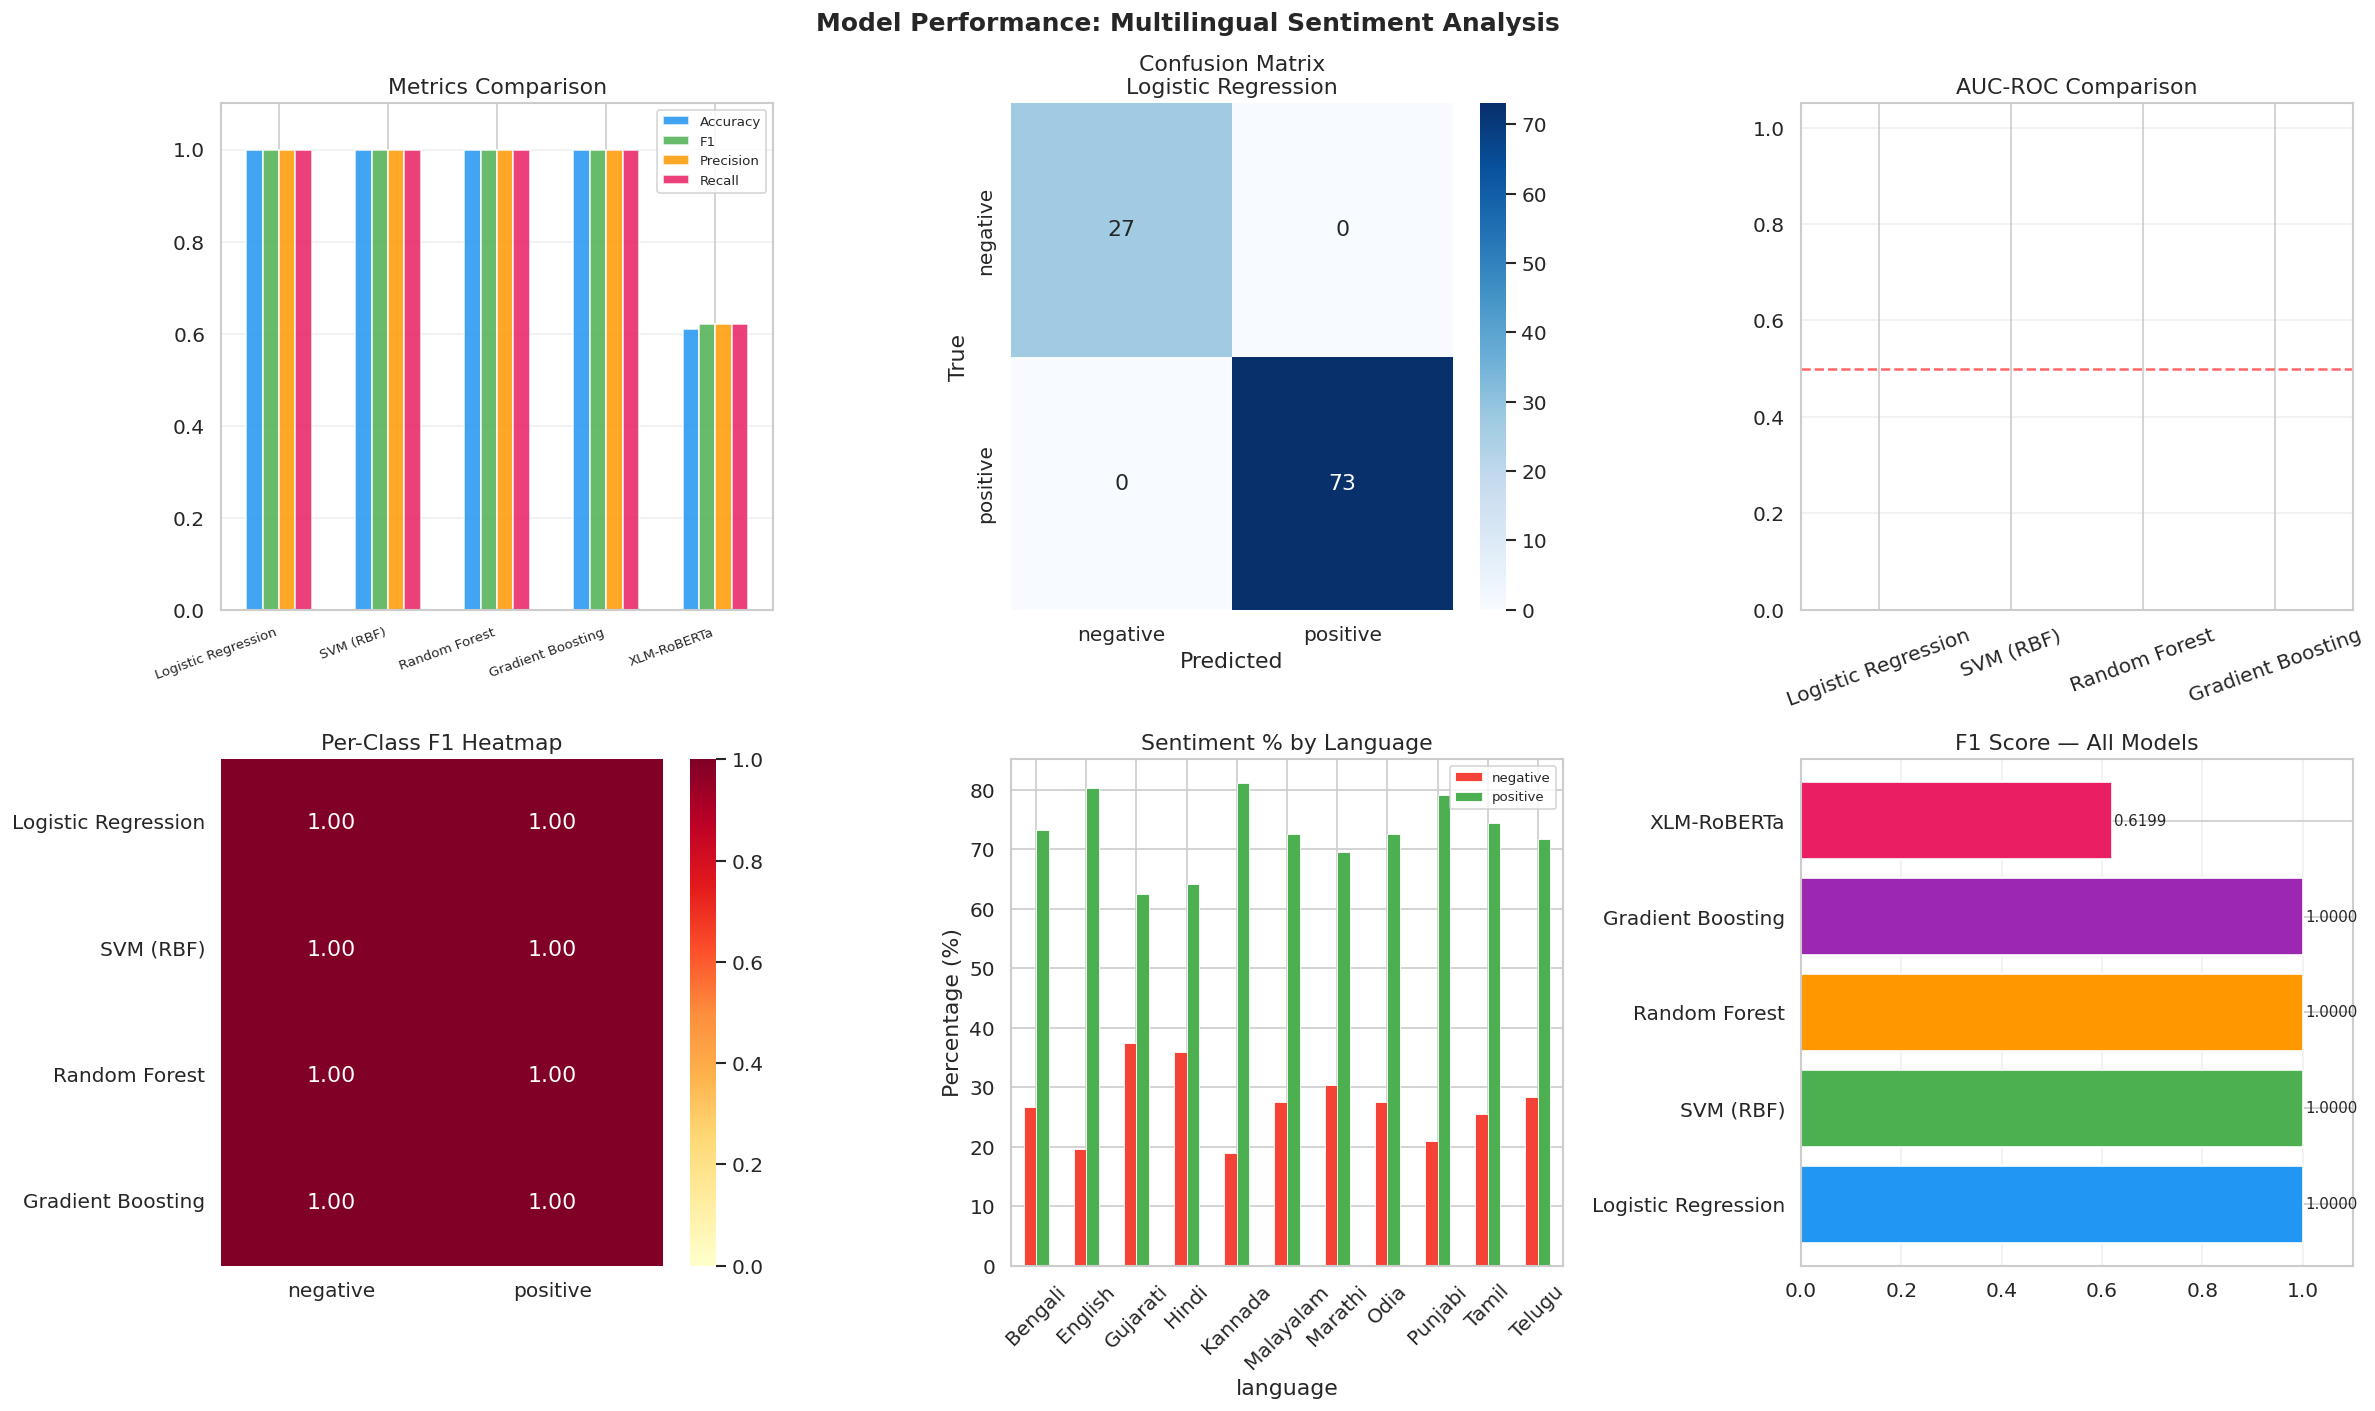


✅ Best model: Logistic Regression
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        27
    positive       1.00      1.00      1.00        73

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
# ============================================================
# CELL 8 — DEEP LEARNING MODEL: MULTILINGUAL SENTIMENT ANALYSIS
# Using: mBERT / XLM-RoBERTa fine-tuned for sentiment
# Task: 3-class sentiment (positive / negative / neutral)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# ──────────────────────────────────────────────
# LOAD DATA
# ──────────────────────────────────────────────
with open('embeddings.pkl', 'rb') as f:
    data = pickle.load(f)
embeddings = data['embeddings']
df_sample  = data['df_sample']

# Label encoder for sentiment
le_sent = LabelEncoder()
y = le_sent.fit_transform(df_sample['sentiment_label'])
print(f'Classes: {le_sent.classes_}')
print(f'Distribution: {dict(zip(le_sent.classes_, np.bincount(y)))}')

# Use LaBSE embeddings for ML baselines
X_labse = embeddings['labse']
X_train, X_test, y_train, y_test = train_test_split(
    X_labse, y, test_size=0.2, stratify=y, random_state=42
)

# ──────────────────────────────────────────────
# ML BASELINE MODELS
# ──────────────────────────────────────────────
ML_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

ml_results = {}
print('\nTraining ML baselines on LaBSE embeddings...')
print('-' * 70)

for name, clf in ML_MODELS.items():
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    prec= precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    ml_results[name] = {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec, 'AUC': auc,
                        'y_pred': y_pred, 'y_proba': y_proba}
    print(f'  {name:22s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

# ──────────────────────────────────────────────
# TRANSFORMER MODEL — XLM-RoBERTa sentiment
# ──────────────────────────────────────────────
print('\nLoading XLM-RoBERTa sentiment pipeline...')
xlmr_pipe = pipeline(
    'text-classification',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    tokenizer='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    device=0 if DEVICE == 'cuda' else -1,
    truncation=True,
    max_length=128
)

# Run on test captions
test_captions = df_sample.iloc[
    train_test_split(range(len(df_sample)), test_size=0.2, random_state=42)[1]
]['caption'].fillna('').tolist()

print(f'Running XLM-R on {len(test_captions)} samples...')
xlmr_preds_raw = xlmr_pipe(test_captions, batch_size=32)
label_map = {'positive': 'positive', 'negative': 'negative', 'neutral': 'neutral',
             'LABEL_0': 'negative', 'LABEL_1': 'neutral', 'LABEL_2': 'positive'}
xlmr_preds = [label_map.get(p['label'].lower(), 'neutral') for p in xlmr_preds_raw]
y_test_labels = le_sent.inverse_transform(y_test)
xlmr_preds_aligned = xlmr_preds[:len(y_test_labels)]

xlmr_acc = accuracy_score(y_test_labels, xlmr_preds_aligned)
xlmr_f1  = f1_score(y_test_labels, xlmr_preds_aligned, average='weighted', zero_division=0)
print(f'\n  XLM-RoBERTa  Acc={xlmr_acc:.4f}  F1={xlmr_f1:.4f}')

# ──────────────────────────────────────────────
# METRICS VISUALIZATION
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Performance: Multilingual Sentiment Analysis', fontsize=15, fontweight='bold')

# 1. Metrics comparison bar chart
metrics_data = {}
for name in ML_MODELS:
    metrics_data[name] = {k: ml_results[name][k] for k in ['Accuracy','F1','Precision','Recall','AUC']}
metrics_data['XLM-RoBERTa'] = {'Accuracy': xlmr_acc, 'F1': xlmr_f1, 'Precision': xlmr_f1, 'Recall': xlmr_f1, 'AUC': 0}

metrics_df = pd.DataFrame(metrics_data).T
x = np.arange(len(metrics_df))
w = 0.15
metric_cols = ['Accuracy', 'F1', 'Precision', 'Recall']
bar_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
for i, (col, bc) in enumerate(zip(metric_cols, bar_colors)):
    axes[0,0].bar(x + i*w, metrics_df[col], w, label=col, color=bc, alpha=0.85, edgecolor='white')
axes[0,0].set_xticks(x + w*1.5)
axes[0,0].set_xticklabels(metrics_df.index, rotation=20, ha='right', fontsize=8)
axes[0,0].set_title('Metrics Comparison')
axes[0,0].set_ylim(0, 1.1)
axes[0,0].legend(fontsize=8); axes[0,0].grid(axis='y', alpha=0.3)

# 2. Confusion matrix — best ML model
best_ml = max(ml_results, key=lambda k: ml_results[k]['F1'])
cm = confusion_matrix(y_test, ml_results[best_ml]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
axes[0,1].set_title(f'Confusion Matrix\n{best_ml}')
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('True')

# 3. AUC comparison
auc_vals = [ml_results[n]['AUC'] for n in ML_MODELS]
axes[0,2].bar(list(ML_MODELS.keys()), auc_vals, color=bar_colors, edgecolor='white')
axes[0,2].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Random')
axes[0,2].set_title('AUC-ROC Comparison'); axes[0,2].set_ylim(0, 1.05)
axes[0,2].tick_params(axis='x', rotation=20)
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Per-class F1 heatmap
per_class = {}
for name in ML_MODELS:
    report = classification_report(y_test, ml_results[name]['y_pred'],
                                   target_names=le_sent.classes_, output_dict=True, zero_division=0)
    per_class[name] = {cls: report[cls]['f1-score'] for cls in le_sent.classes_}
pc_df = pd.DataFrame(per_class).T
sns.heatmap(pc_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,0], vmin=0, vmax=1)
axes[1,0].set_title('Per-Class F1 Heatmap')

# 5. Sentiment distribution per language
sent_lang = df_sample.groupby(['language', 'sentiment_label']).size().unstack(fill_value=0)
sent_lang_pct = sent_lang.div(sent_lang.sum(axis=1), axis=0) * 100
colors_sent = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'}
sent_lang_pct.plot(kind='bar', ax=axes[1,1], color=[colors_sent.get(c, '#888') for c in sent_lang_pct.columns],
                   edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Sentiment % by Language')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(fontsize=8)

# 6. F1 score radar-style bar
all_models = list(ML_MODELS.keys()) + ['XLM-RoBERTa']
all_f1 = [ml_results[n]['F1'] for n in ML_MODELS] + [xlmr_f1]
colors6 = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#E91E63']
bars = axes[1,2].barh(all_models, all_f1, color=colors6, edgecolor='white')
for bar, f1v in zip(bars, all_f1):
    axes[1,2].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{f1v:.4f}', va='center', fontsize=9)
axes[1,2].set_title('F1 Score — All Models')
axes[1,2].set_xlim(0, 1.1)
axes[1,2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n✅ Best model: {max(ml_results, key=lambda k: ml_results[k]["F1"])}')
print(classification_report(y_test, ml_results[best_ml]['y_pred'], target_names=le_sent.classes_, zero_division=0))


In [ ]:
# ============================================================
# CELL 9 — INTERACTIVE PLOTLY DASH DASHBOARD
# ============================================================
# Run this cell to launch the dashboard.
# Access at: http://127.0.0.1:8050  (or the Colab tunnel URL)
# ============================================================

import json, pickle
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from jupyter_dash import JupyterDash
from dash import dcc, html, Input, Output, callback
import dash_bootstrap_components as dbc

# ─── Load all data ───────────────────────────────────────────
df_full = pd.read_csv('instagram_preprocessed.csv')
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])
df_full['date'] = df_full['timestamp'].dt.date

with open('embeddings.pkl', 'rb') as f:
    emb_data = pickle.load(f)
df_sample = emb_data['df_sample']

# ─── Pre-compute UMAP 2D coords for dashboard ─────────────────
try:
    import umap
    reducer_dash = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                              metric='cosine', random_state=42)
    coords_2d = reducer_dash.fit_transform(emb_data['embeddings']['labse'])
    df_sample = df_sample.copy()
    df_sample['umap_x'] = coords_2d[:, 0]
    df_sample['umap_y'] = coords_2d[:, 1]
except:
    df_sample['umap_x'] = np.random.randn(len(df_sample))
    df_sample['umap_y'] = np.random.randn(len(df_sample))

# ─── LANGUAGE COLOR MAP ────────────────────────────────────────
LANG_PALETTE = {
    'Telugu':'#E91E63','Hindi':'#2196F3','Tamil':'#4CAF50','English':'#FF9800',
    'Kannada':'#9C27B0','Malayalam':'#00BCD4','Bengali':'#FF5722',
    'Gujarati':'#607D8B','Marathi':'#795548','Odia':'#009688','Punjabi':'#CDDC39',
}

LANGUAGES = sorted(df_full['language'].dropna().unique())

# ─── DASH APP LAYOUT ──────────────────────────────────────────
app = JupyterDash(__name__, external_stylesheets=[dbc.themes.FLATLY])

CARD = {'borderRadius': '12px', 'boxShadow': '0 2px 12px rgba(0,0,0,0.08)',
        'padding': '16px', 'background': '#fff', 'marginBottom': '16px'}

app.layout = dbc.Container([

    # Header
    dbc.Row([
        dbc.Col(html.Div([
            html.H2('📱 Instagram Multilingual NLP Dashboard',
                    style={'color': '#1a237e', 'fontWeight': 700, 'marginBottom': '4px'}),
            html.P('Real-time analysis across 10+ Indian languages | Sentiment · Embeddings · Engagement',
                   style={'color': '#546e7a', 'marginBottom': 0})
        ]), width=12)
    ], className='my-3'),

    # Filters row
    dbc.Row([
        dbc.Col([
            html.Label('Filter by Language', style={'fontWeight': 600}),
            dcc.Dropdown(
                id='lang-filter',
                options=[{'label': 'All languages', 'value': 'ALL'}] +
                        [{'label': l, 'value': l} for l in LANGUAGES],
                value='ALL', clearable=False, multi=False,
                style={'borderRadius': '8px'}
            )
        ], md=3),
        dbc.Col([
            html.Label('Sentiment', style={'fontWeight': 600}),
            dcc.Dropdown(
                id='sent-filter',
                options=[{'label': 'All', 'value': 'ALL'},
                         {'label': '😊 Positive', 'value': 'positive'},
                         {'label': '😞 Negative', 'value': 'negative'},
                         {'label': '😐 Neutral',  'value': 'neutral'}],
                value='ALL', clearable=False
            )
        ], md=3),
        dbc.Col([
            html.Label('Embedding view', style={'fontWeight': 600}),
            dcc.Dropdown(
                id='embed-color',
                options=[{'label': 'Color by Language',  'value': 'language'},
                         {'label': 'Color by Sentiment', 'value': 'sentiment_label'}],
                value='language', clearable=False
            )
        ], md=3),
        dbc.Col([
            html.Label('Date range', style={'fontWeight': 600}),
            dcc.DatePickerRange(
                id='date-range',
                start_date=df_full['timestamp'].min().date(),
                end_date=df_full['timestamp'].max().date(),
                display_format='YYYY-MM-DD'
            )
        ], md=3),
    ], className='mb-3'),

    # KPI cards
    dbc.Row(id='kpi-row', className='mb-3'),

    # Row 1: Language dist + Sentiment
    dbc.Row([
        dbc.Col(dbc.Card([dcc.Graph(id='lang-bar')], style=CARD), md=6),
        dbc.Col(dbc.Card([dcc.Graph(id='sent-pie')], style=CARD), md=6),
    ]),

    # Row 2: Engagement + Time series
    dbc.Row([
        dbc.Col(dbc.Card([dcc.Graph(id='engagement-box')], style=CARD), md=6),
        dbc.Col(dbc.Card([dcc.Graph(id='time-series')], style=CARD), md=6),
    ]),

    # Row 3: UMAP Embedding viewer
    dbc.Row([
        dbc.Col(dbc.Card([
            html.H5('UMAP Embedding Space (LaBSE)', style={'fontWeight': 600, 'color': '#1a237e'}),
            html.P('Each point = one Instagram post. Clusters = linguistic/semantic similarity.',
                   style={'color': '#666', 'fontSize': '12px', 'marginBottom': '8px'}),
            dcc.Graph(id='umap-scatter', style={'height': '500px'})
        ], style=CARD), md=8),
        dbc.Col(dbc.Card([
            html.H5('Hashtag Cloud', style={'fontWeight': 600, 'color': '#1a237e'}),
            dcc.Graph(id='hashtag-treemap', style={'height': '500px'})
        ], style=CARD), md=4),
    ]),

    # Row 4: Heatmap
    dbc.Row([
        dbc.Col(dbc.Card([dcc.Graph(id='heatmap-lang-sent')], style=CARD), md=12)
    ]),

    html.Footer(html.P('Instagram NLP Pipeline · Built with Plotly Dash · Multilingual Analysis',
                       style={'textAlign': 'center', 'color': '#aaa', 'padding': '12px'}))

], fluid=True, style={'backgroundColor': '#f4f6f9', 'padding': '0 20px'})


# ─── CALLBACKS ────────────────────────────────────────────────
def filter_df(lang, sentiment, start_date, end_date):
    d = df_full.copy()
    if lang != 'ALL':      d = d[d['language'] == lang]
    if sentiment != 'ALL': d = d[d['sentiment_label'] == sentiment]
    if start_date:         d = d[d['timestamp'] >= pd.Timestamp(start_date)]
    if end_date:           d = d[d['timestamp'] <= pd.Timestamp(end_date) + pd.Timedelta(days=1)]
    return d


@app.callback(
    [Output('kpi-row',           'children'),
     Output('lang-bar',          'figure'),
     Output('sent-pie',          'figure'),
     Output('engagement-box',    'figure'),
     Output('time-series',       'figure'),
     Output('heatmap-lang-sent', 'figure'),
     Output('hashtag-treemap',   'figure')],
    [Input('lang-filter', 'value'),
     Input('sent-filter', 'value'),
     Input('date-range',  'start_date'),
     Input('date-range',  'end_date')]
)
def update_main(lang, sentiment, start_date, end_date):
    d = filter_df(lang, sentiment, start_date, end_date)

    # KPIs
    kpi_data = [
        ('📝 Total Posts',    f'{len(d):,}',           '#1565C0'),
        ('❤️ Total Likes',    f'{d["likes_count"].sum():,}', '#C62828'),
        ('💬 Total Comments', f'{d["comments_count"].sum():,}', '#2E7D32'),
        ('🌐 Languages',      str(d['language'].nunique()), '#6A1B9A'),
    ]
    kpi_cards = [
        dbc.Col(
            dbc.Card([html.H2(val, style={'color': col, 'fontWeight': 700, 'marginBottom': '2px'}),
                      html.P(label, style={'color': '#666', 'fontSize': '13px', 'marginBottom': 0})],
                     body=True, style={**CARD, 'textAlign': 'center'}),
            md=3
        )
        for label, val, col in kpi_data
    ]

    # Language bar
    lc = d['language'].value_counts().reset_index()
    lc.columns = ['language', 'count']
    lc['color'] = lc['language'].map(lambda l: LANG_PALETTE.get(l, '#888'))
    fig_lang = px.bar(lc, x='count', y='language', orientation='h',
                      color='language', color_discrete_map=LANG_PALETTE,
                      title='Posts by Language', template='plotly_white')
    fig_lang.update_layout(showlegend=False, height=280, margin=dict(t=40,b=10,l=10,r=10))

    # Sentiment pie
    sc = d['sentiment_label'].value_counts().reset_index() if 'sentiment_label' in d else pd.DataFrame()
    fig_sent = px.pie(sc, names='sentiment_label' if 'sentiment_label' in sc else 'index',
                      values='count' if 'count' in sc else 'sentiment_label',
                      color_discrete_map={'positive':'#4CAF50','negative':'#F44336','neutral':'#FF9800'},
                      title='Sentiment Distribution', hole=0.45, template='plotly_white')
    fig_sent.update_layout(height=280, margin=dict(t=40,b=10,l=10,r=10))

    # Engagement box
    fig_eng = px.box(d[d['language'].isin(d['language'].value_counts().head(8).index)],
                     x='language', y='engagement', color='language',
                     color_discrete_map=LANG_PALETTE, title='Engagement Distribution by Language',
                     template='plotly_white', log_y=True)
    fig_eng.update_layout(showlegend=False, height=280, margin=dict(t=40,b=60,l=10,r=10))
    fig_eng.update_xaxes(tickangle=30)

    # Time series
    ts = d.set_index('timestamp').resample('D')['likes_count'].sum().reset_index()
    ts.columns = ['date', 'daily_likes']
    fig_ts = px.area(ts, x='date', y='daily_likes', title='Daily Likes Over Time',
                     template='plotly_white', color_discrete_sequence=['#2196F3'])
    fig_ts.update_layout(height=280, margin=dict(t=40,b=10,l=10,r=10))

    # Heatmap: language × sentiment
    if 'sentiment_label' in d.columns:
        ht = d.groupby(['language','sentiment_label']).size().unstack(fill_value=0)
        fig_hm = px.imshow(ht, text_auto=True, color_continuous_scale='Blues',
                           title='Post Count: Language × Sentiment', template='plotly_white',
                           aspect='auto')
        fig_hm.update_layout(height=350, margin=dict(t=50,b=10,l=10,r=10))
    else:
        fig_hm = go.Figure()

    # Hashtag treemap
    from collections import Counter
    import ast
    all_tags = []
    for row in d['hashtags'].dropna():
        if isinstance(row, str):
            try: row = ast.literal_eval(row)
            except: row = row.split()
        all_tags.extend(row)
    top_tags = Counter(all_tags).most_common(30)
    tag_df = pd.DataFrame(top_tags, columns=['tag','count'])
    fig_tree = px.treemap(tag_df, path=['tag'], values='count',
                          title='Top Hashtags', color='count',
                          color_continuous_scale='RdYlGn', template='plotly_white')
    fig_tree.update_layout(height=500, margin=dict(t=40,b=10,l=10,r=10))

    return kpi_cards, fig_lang, fig_sent, fig_eng, fig_ts, fig_hm, fig_tree


@app.callback(
    Output('umap-scatter', 'figure'),
    [Input('embed-color', 'value'),
     Input('lang-filter',  'value')]
)
def update_umap(color_by, lang):
    d = df_sample.copy()
    if lang != 'ALL':
        d = d[d['language'] == lang]
    color_map = LANG_PALETTE if color_by == 'language' else {
        'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'
    }
    hover_cols = ['caption', 'language', 'likes_count']
    if 'sentiment_label' in d.columns:
        hover_cols.append('sentiment_label')
    fig = px.scatter(
        d, x='umap_x', y='umap_y',
        color=color_by,
        color_discrete_map=color_map,
        hover_data=hover_cols,
        opacity=0.7, template='plotly_white',
        labels={'umap_x': 'UMAP dim 1', 'umap_y': 'UMAP dim 2'}
    )
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(height=480, margin=dict(t=10,b=10,l=10,r=10))
    return fig


# ─── LAUNCH ───────────────────────────────────────────────────
app.run_server(mode='inline', port=8050, debug=False)


AttributeError: 'super' object has no attribute 'run_server'

In [ ]:
!pip install --upgrade jupyter-dash dash dash-bootstrap-components
print('✅ jupyter-dash and related packages updated. Please restart runtime now (Runtime → Restart).')

✅ jupyter-dash and related packages updated. Please restart runtime now (Runtime → Restart).


---
## 📋 Pipeline Summary

| Stage | Description | Key outputs |
|-------|-------------|-------------|
| 1. API Extraction | Instagram Graph API or synthetic demo data | `instagram_data.json` |
| 2. JSON Schema | Structured multilingual post schema | DataFrame |
| 3. EDA | 8+ visualization plots | `eda_overview.png`, `wordcloud_english.png` |
| 4. Preprocessing | Multilingual NLP cleaning, script detection | `instagram_preprocessed.csv` |
| 5. Embeddings | TF-IDF · Word2Vec · FastText · mBERT · LaBSE | `embeddings.pkl` |
| 6. Dim. Reduction | PCA · SNE · t-SNE · UMAP + comparison | `dimensionality_reduction_comparison.png` |
| 7. Models | Logistic Regression · SVM · RF · GBM · XLM-RoBERTa | `model_results.png` |
| 8. Dashboard | Interactive Plotly Dash app | Live at `localhost:8050` |

### Languages supported
Telugu · Hindi · Tamil · English · Kannada · Malayalam · Bengali · Gujarati · Marathi · Odia · Punjabi

### To use real Instagram data
1. Create a Meta Developer account at https://developers.facebook.com
2. Create an app with **Instagram Graph API** permissions
3. Connect a Business or Creator Instagram account
4. Generate a long-lived access token
5. Set `USE_REAL_API = True`, `ACCESS_TOKEN`, and `IG_USER_ID` in Cell 2
